In [24]:
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader # for image + table+ text kind of. data use --> unstructured.io libraries
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_chroma import Chroma
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
load_dotenv()

True

In [4]:
# 1 load the pdf files
pdf_loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf")
raw_docs = pdf_loader.load()



In [ ]:
# len(raw_docs)
# raw_docs[0].page_content

'Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document'

In [9]:
# 2 . split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = text_splitter.split_documents(raw_docs)
print(len(chunks))

51


In [ ]:
# chunks[0]

Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-04-18T21:49:03+05:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-04-18T21:49:03+05:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '../documents/evs_oil_price_shock.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'}, page_content='Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document')

In [14]:
# print(chunks[1].page_content)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [17]:
vectorstore = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
    # persist_directory="../chroma_db". # this is optional for this run
)

vectorstore.add_documents(chunks)

# retrieval strategy
retriever = vectorstore.as_retriever( search_kwargs={"k": 2})

In [22]:
class AgenticRAGState(MessagesState):
    query: str
    retrieved_docs: list[Document]
    context: str
    generation: str

llm = ChatOpenAI(model="gpt-5-mini")

In [23]:
# lets define the node --> 
def retrieve(state: AgenticRAGState):
    docs = retriever.invoke(state['query'])
    context = "\n\n".join([doc.page_content for doc in docs])
    return {"retrieved_docs": docs, "context": context}


In [25]:
def generate(state: AgenticRAGState):
    query = state['query']
    context = state['context']
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
        ("human", query)
    ])
    chain = prompt_template | llm | StrOutputParser()

    response = chain.invoke({"context": context, "query": query})
    return {"generation": response}


In [26]:
graph_builder = StateGraph(AgenticRAGState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

# now we will connect them using edges
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)



In [27]:
graph = graph_builder.compile()

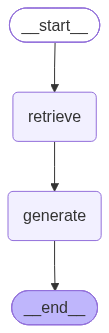

In [28]:
graph

In [29]:
#now we can test it ??
test_query = "How will EVS impact oil demand in the next decade?"
result = graph.invoke({"query": test_query,"messages": []})

In [30]:
result

{'messages': [],
 'query': 'How will EVS impact oil demand in the next decade?',
 'retrieved_docs': [Document(id='f6ae22bc-208a-4ea9-9036-85e170826be9', metadata={'trapped': '/False', 'author': '(anonymous)', 'producer': 'ReportLab PDF Library - (opensource)', 'creationdate': '2026-04-18T21:49:03+05:00', 'creator': '(unspecified)', 'keywords': '', 'subject': '(unspecified)', 'moddate': '2026-04-18T21:49:03+05:00', 'title': '(anonymous)', 'source': '../documents/evs_oil_price_shock.pdf', 'page_label': '4', 'total_pages': 15, 'page': 3}, page_content='Energy Agency, and McKinsey collectively project that EVs will account for between 40 and\n60 percent of new vehicle sales globally by 2030. The stock of EVs on the road — which\nmatters more than annual sales for oil displacement — is projected to grow from roughly 40\nmillion vehicles today to between 300 and 500 million by the early 2030s. Whether this is\nsufficient to materially alter the oil price formation process is the central ques

In [32]:
print(result['generation'])

Short answer
EV adoption will be a material downward force on oil demand over the next decade, but it is not certain that it will be large enough by itself to fundamentally change global oil price formation.

Why
- Adoption trajectory: Major forecasters project EVs will make up 40–60% of new passenger and light‑commercial vehicle sales by 2030.  
- Fleet scale: the EV stock is expected to grow from roughly 40 million today to about 300–500 million by the early 2030s — and it is the cumulative stock, not just annual sales, that determines fuel displacement.  
- Scope limitation: this analysis concerns passenger and light‑commercial vehicles. Heavy trucking, aviation, shipping and petrochemical feedstock (which together account for roughly 43% of oil consumption) are not primarily affected by passenger EVs and therefore leave a large portion of baseline oil demand intact.

Implication
Because passenger/light‑commercial electrification will remove a meaningful slice of oil consumption, it

In [34]:
print(len(result['retrieved_docs']))

2


In [35]:
test_query = "who is PM of india"
result = graph.invoke({"query": test_query,"messages": []})

In [36]:
result

{'messages': [],
 'query': 'who is PM of india',
 'retrieved_docs': [Document(id='7b3068af-10d4-4e5c-842e-212d804fa106', metadata={'trapped': '/False', 'keywords': '', 'total_pages': 15, 'creationdate': '2026-04-18T21:49:03+05:00', 'author': '(anonymous)', 'creator': '(unspecified)', 'moddate': '2026-04-18T21:49:03+05:00', 'source': '../documents/evs_oil_price_shock.pdf', 'page': 14, 'page_label': '15', 'subject': '(unspecified)', 'title': '(anonymous)', 'producer': 'ReportLab PDF Library - (opensource)'}, page_content='manage the elevated transition-period vulnerability. The world with 500 million EVs will be\nmeaningfully less exposed to the oil price shocks that have periodically destabilized\neconomies for the past five decades, but it will not be immune to them.'),
  Document(id='02a06000-df51-4116-9af3-0d073a75ee09', metadata={'moddate': '2026-04-18T21:49:03+05:00', 'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-04-18T21:49:0